Load target and pattern images and store Height and width of the flag used later for alignment and warping.

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

target = cv2.imread('flag.png')
pattern = cv2.imread('pattern.png')
h, w = target.shape[:2]

1. Applying perspective wrap by coordination the pattern on to the flag coordinates.
2. Calculates transformation matrix from pattern to flag shape
3. Next,Warps pattern to match perspective of the flag.

In [3]:
# Define the destination (target) points in the original image where the pattern should be mapped
src_pts = np.float32([[280, 90], [290, 650], [980, 810], [1030, 250]])

# Define the source points as the corners of the pattern image
dst_pts = np.float32([[0, 0], [pattern.shape[1], 0],
                      [pattern.shape[1], pattern.shape[0]], [0, pattern.shape[0]]])

# Compute the perspective transformation matrix from the pattern to the destination shape
matrix = cv2.getPerspectiveTransform(dst_pts, src_pts)

# Apply the perspective warp to the pattern to fit it into the target area
warped = cv2.warpPerspective(pattern, matrix, (w, h))


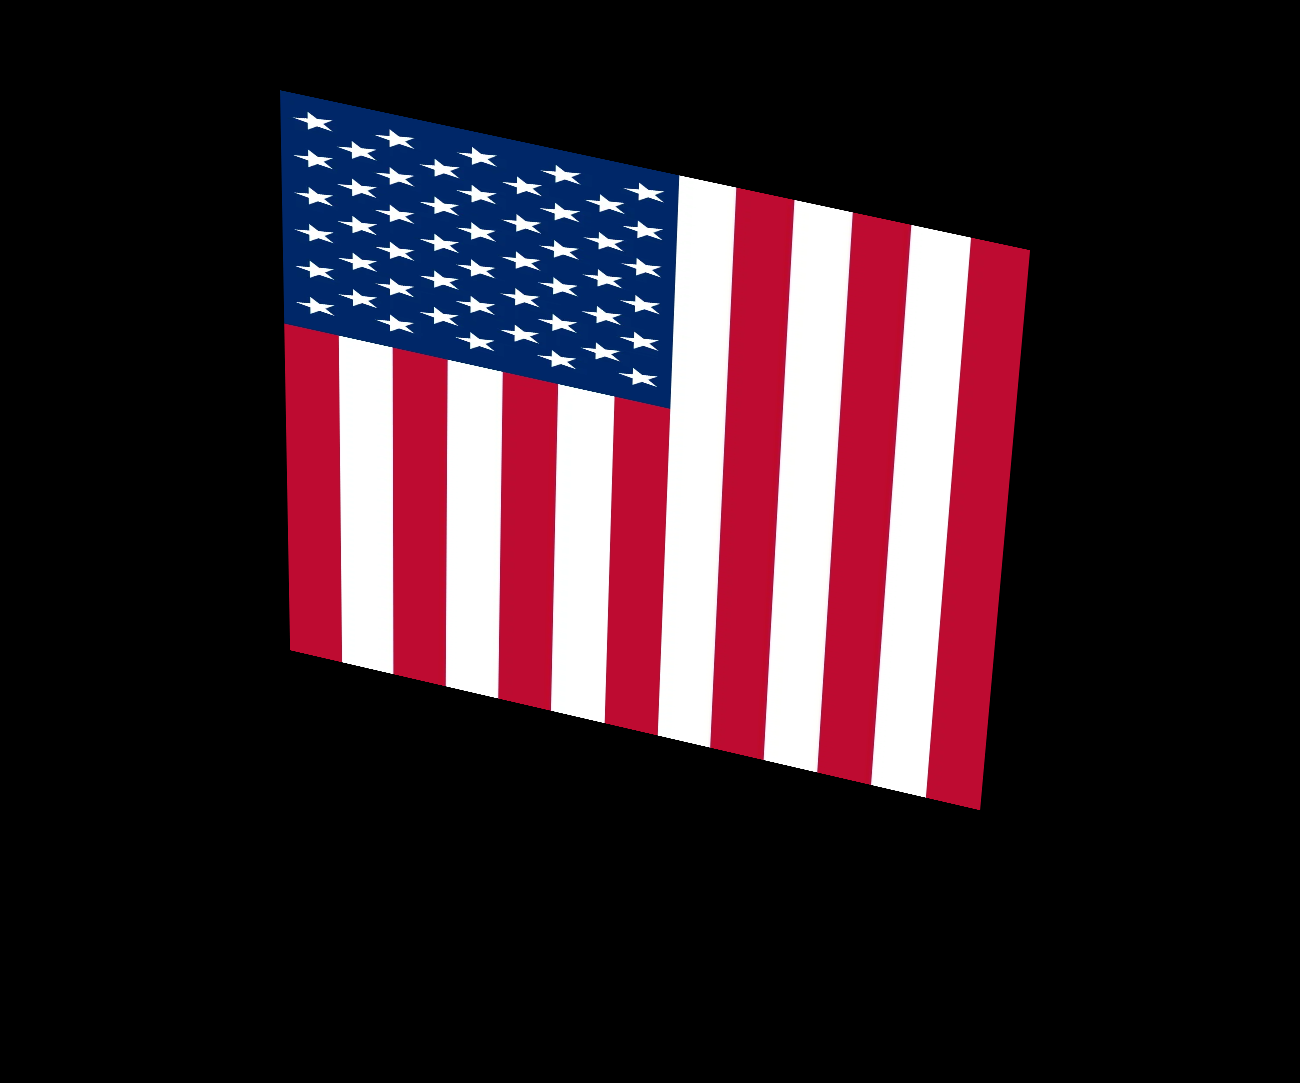

In [12]:
cv2_imshow(warped)

 Create Feathered Alpha Mask.
 1. Converts warped image to grayscale and creates a binary mask to identify non-transparent area


In [4]:
# Convert the warped image to grayscale for mask creation
gray_warped = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

# Create a binary mask where non-black pixels are set to 255 (white), others to 0 (black)
_, mask = cv2.threshold(gray_warped, 1, 255, cv2.THRESH_BINARY)


1. Compute how far each pixel is from the edge of the mask.

2. Creates a soft feathered alpha mask for smooth blending at
   the edges.
3. Sharpens fall-off to make the center more opaque and edges  
   more transparent

In [5]:
# Compute distance transform: each pixel gets distance to the nearest zero (edge) in the mask
dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)

# Normalize the distance map to the range [0, 1] to use as alpha blending weights
alpha = cv2.normalize(dist, None, 0, 1.0, cv2.NORM_MINMAX)

# Apply a wide Gaussian blur to create a soft transition at the mask edges
alpha = cv2.GaussianBlur(alpha, (31, 31), 0)

# Enhance edge softness by steepening the alpha falloff (optional tweak)
alpha = np.power(alpha, 1.5)


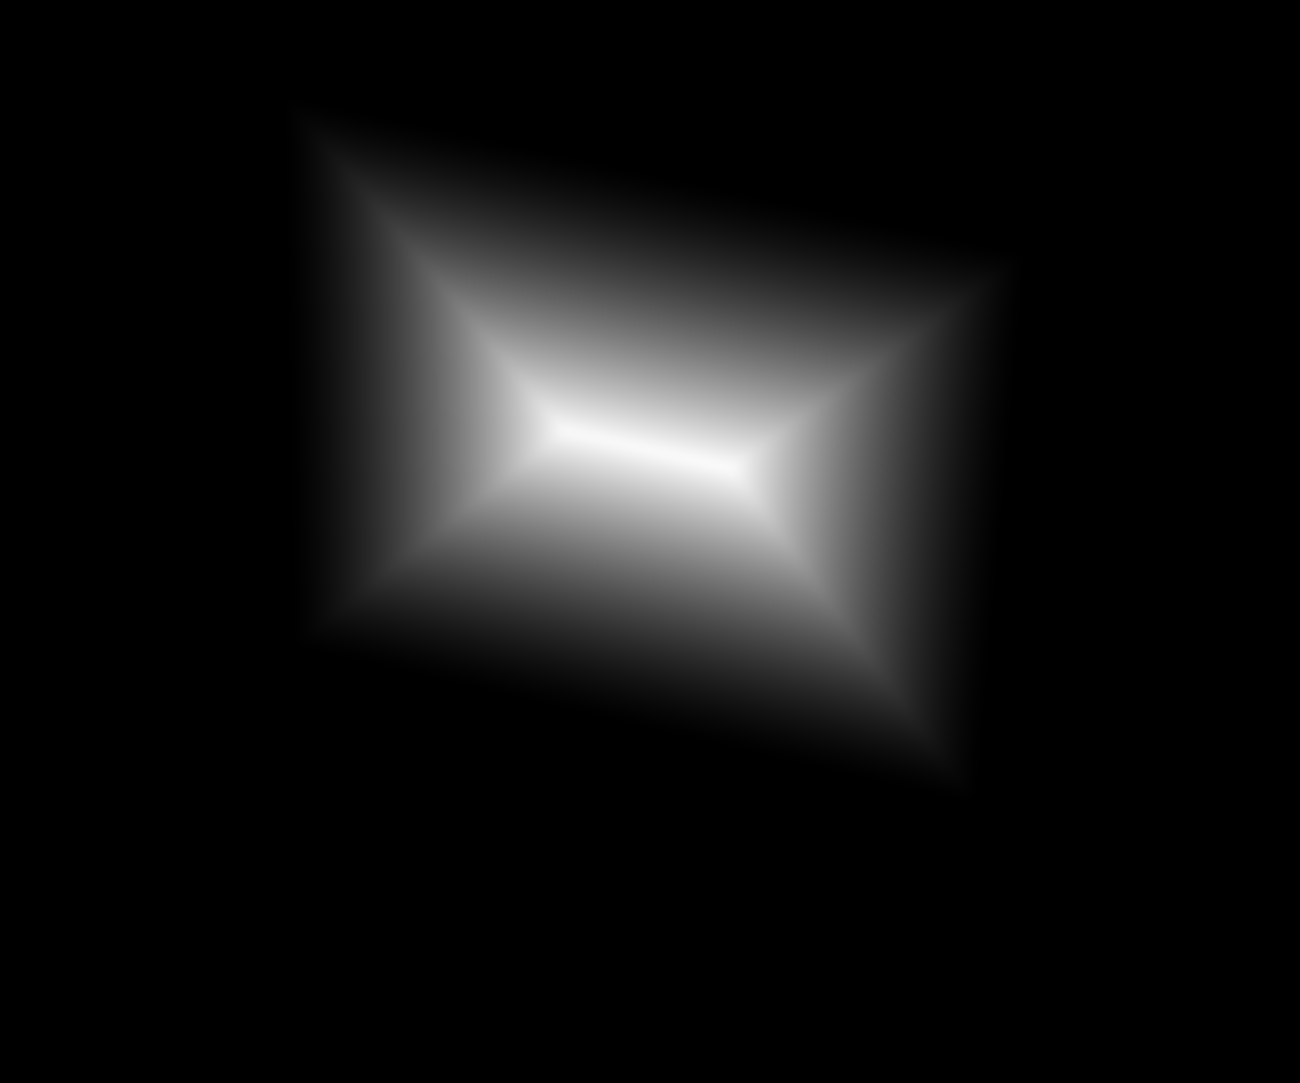

In [13]:
cv2_imshow((alpha * 255).astype(np.uint8))


**Extract Fold Deformation from the Flag**
1. CLAHE (Contrast Limited Adaptive Histogram Equalization): Enhances local contrast to reveal fold structure.
2. Sobel operator computes gradients to detect intensity changes (i.e., folds)
3. Blurred to smooth the deformation map.
4. Generates a deformation map based on folds — simulates cloth stretching or bending.
5. Remaps the warped pattern using gradient deformation to follow the folds of the flag.

In [7]:
# Convert the target (e.g., flag) image to grayscale
gray = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)

# Enhance local contrast using CLAHE to better highlight folds and texture
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

# Compute horizontal and vertical gradients using the Sobel operator
dx = cv2.Sobel(enhanced, cv2.CV_32F, 1, 0, ksize=5)
dy = cv2.Sobel(enhanced, cv2.CV_32F, 0, 1, ksize=5)

# Blur the gradients to smooth out noise and produce more natural warping
dx = cv2.GaussianBlur(dx, (9, 9), 0)
dy = cv2.GaussianBlur(dy, (9, 9), 0)

# Generate coordinate maps for remapping
map_x, map_y = np.meshgrid(np.arange(w), np.arange(h))

# Add the scaled gradient displacement to the coordinate maps
map_x = map_x.astype(np.float32) + 3 * dx / 255.0
map_y = map_y.astype(np.float32) + 3 * dy / 255.0

# Remap the warped image using the deformation maps to simulate folds
deformed = cv2.remap(warped, map_x, map_y, interpolation=cv2.INTER_LINEAR)


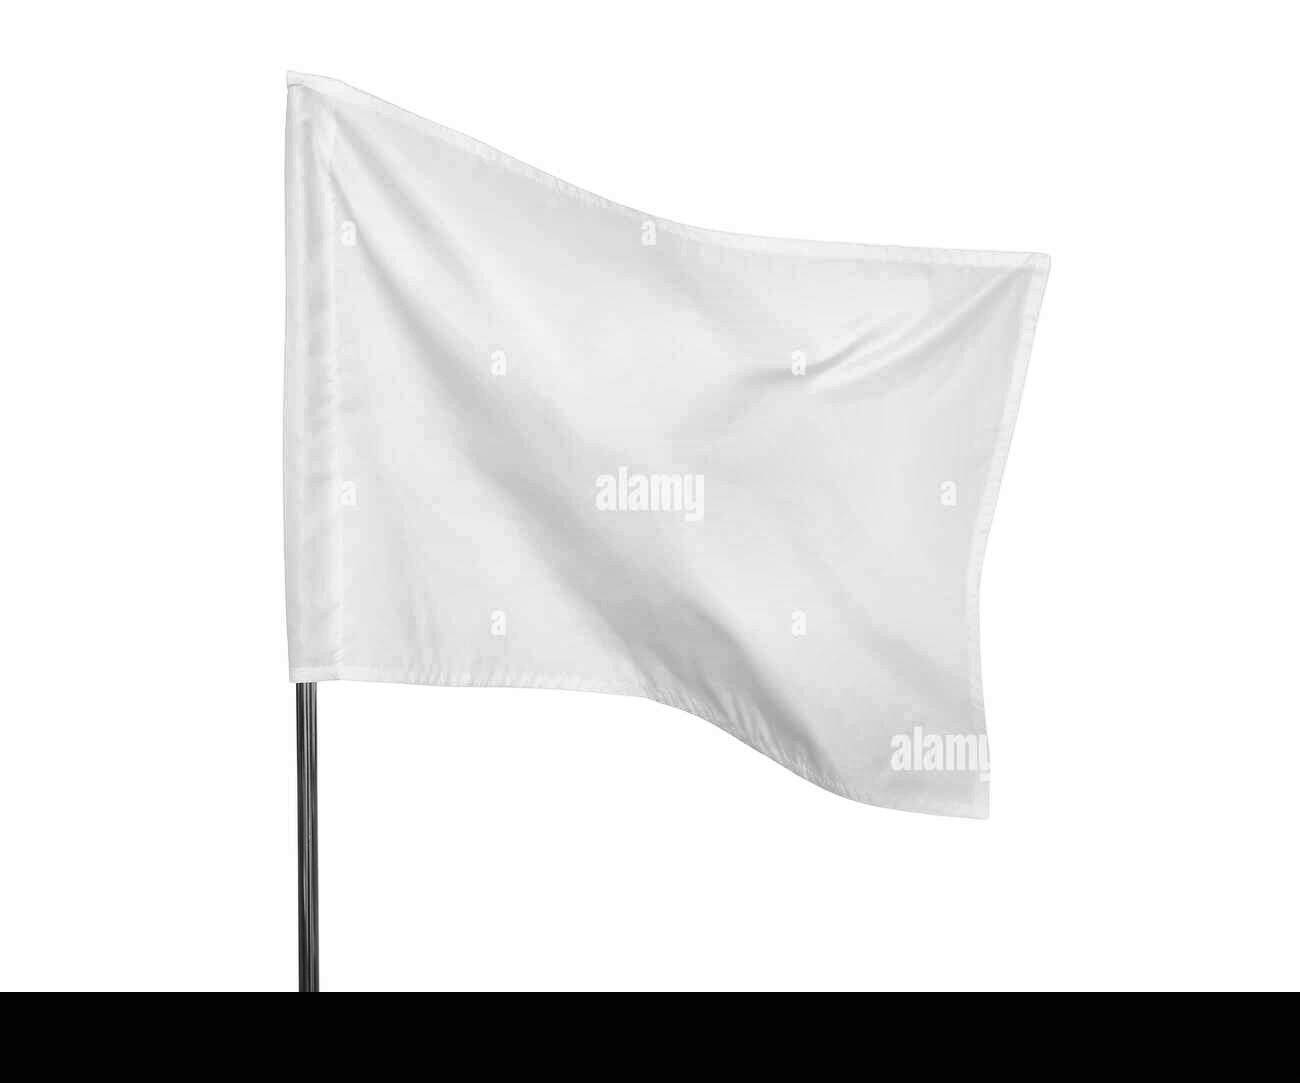

In [14]:
cv2_imshow(enhanced)


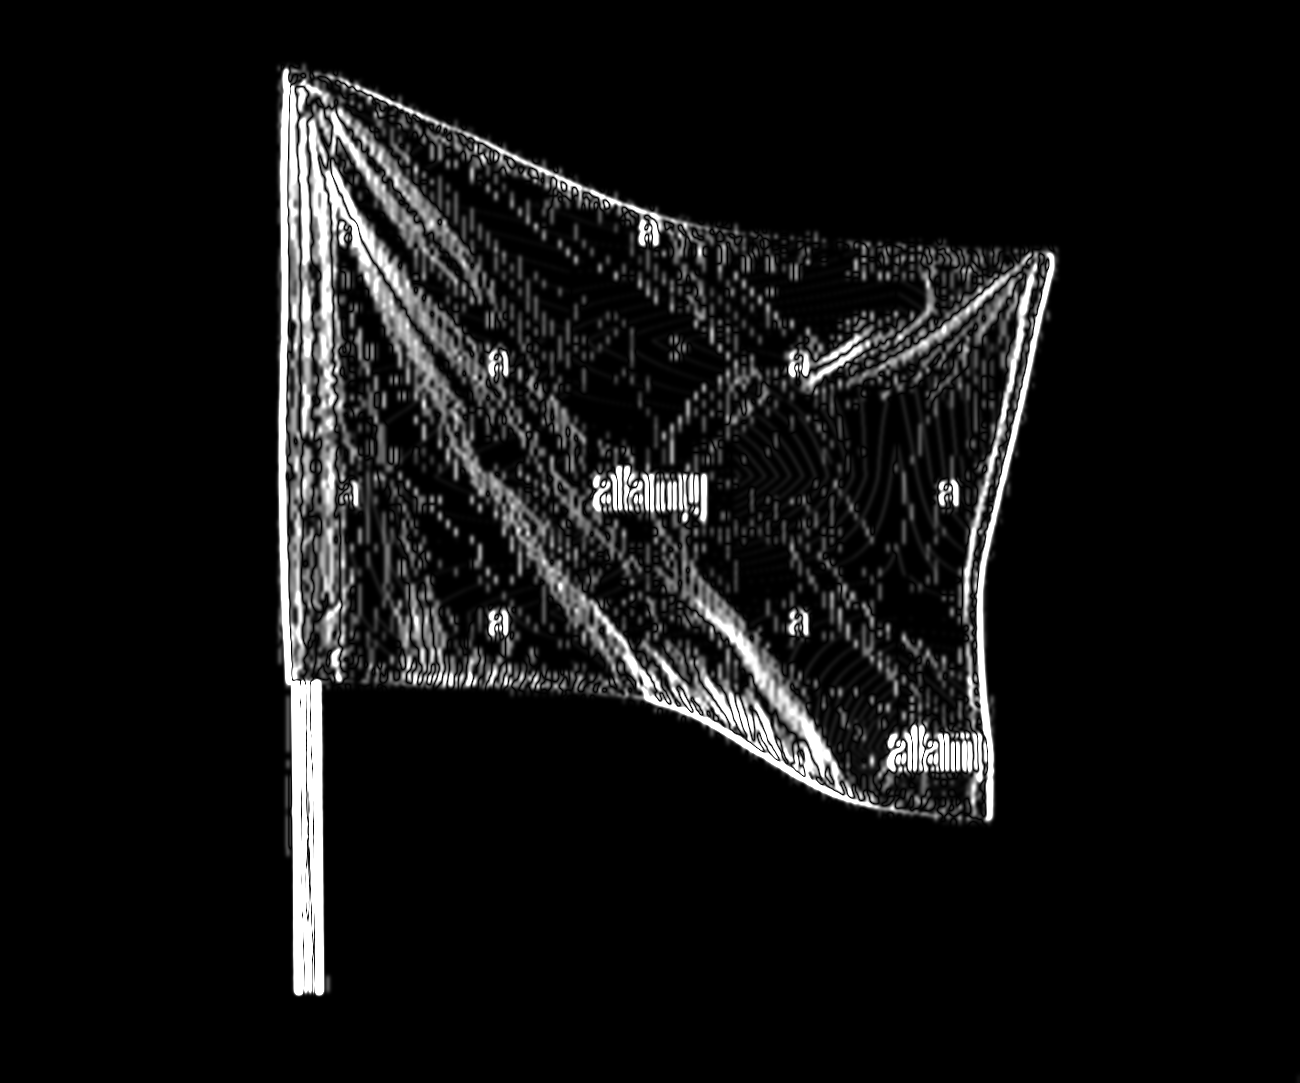

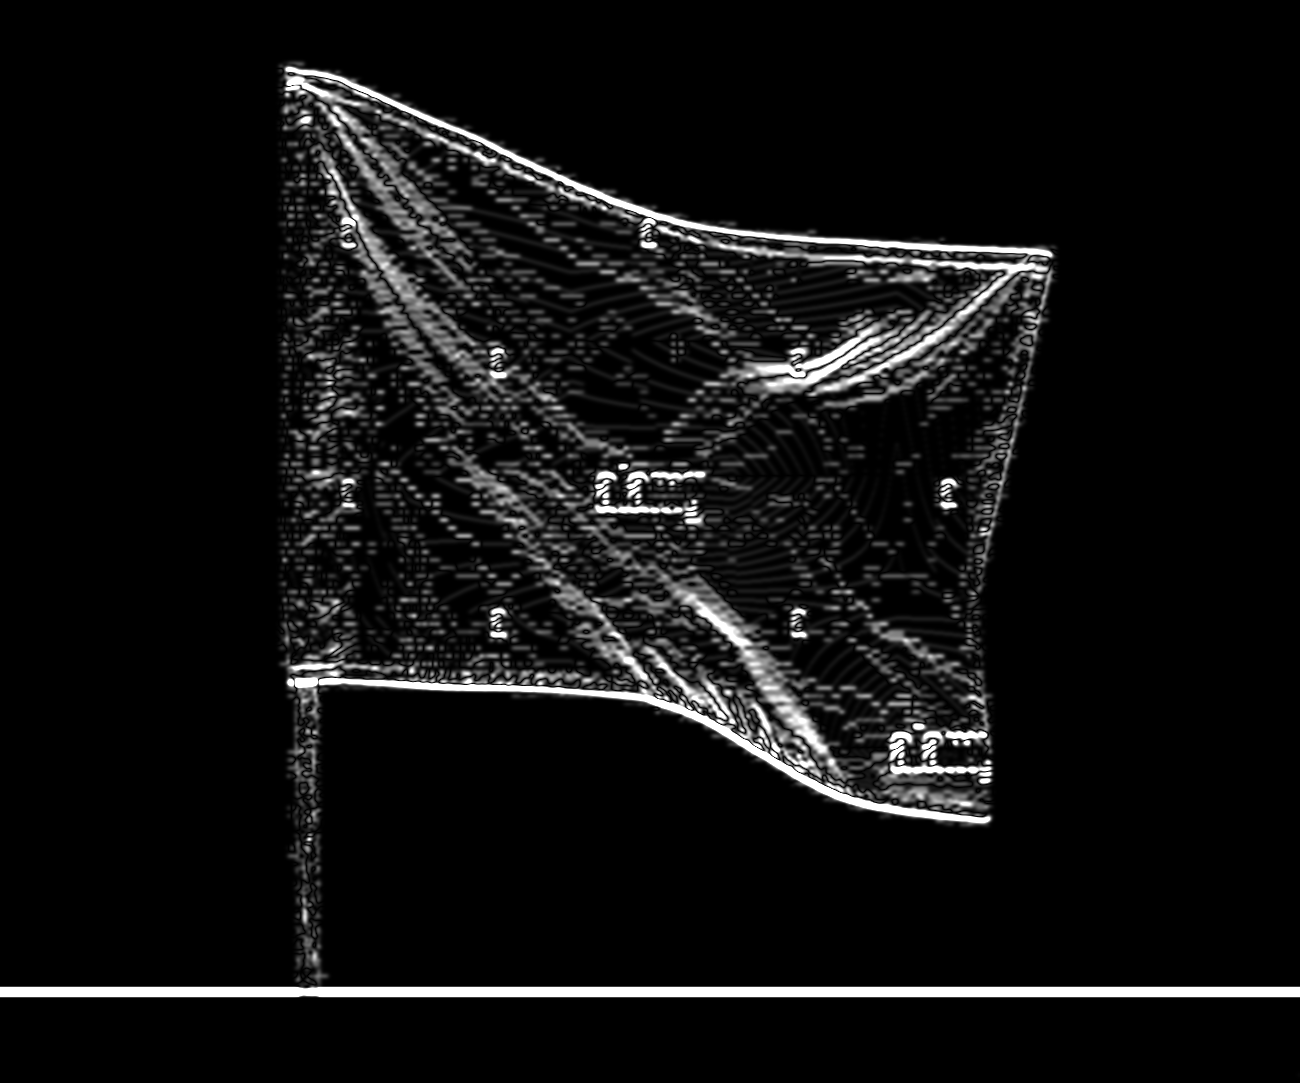

In [15]:
cv2_imshow(cv2.convertScaleAbs(dx))
cv2_imshow(cv2.convertScaleAbs(dy))


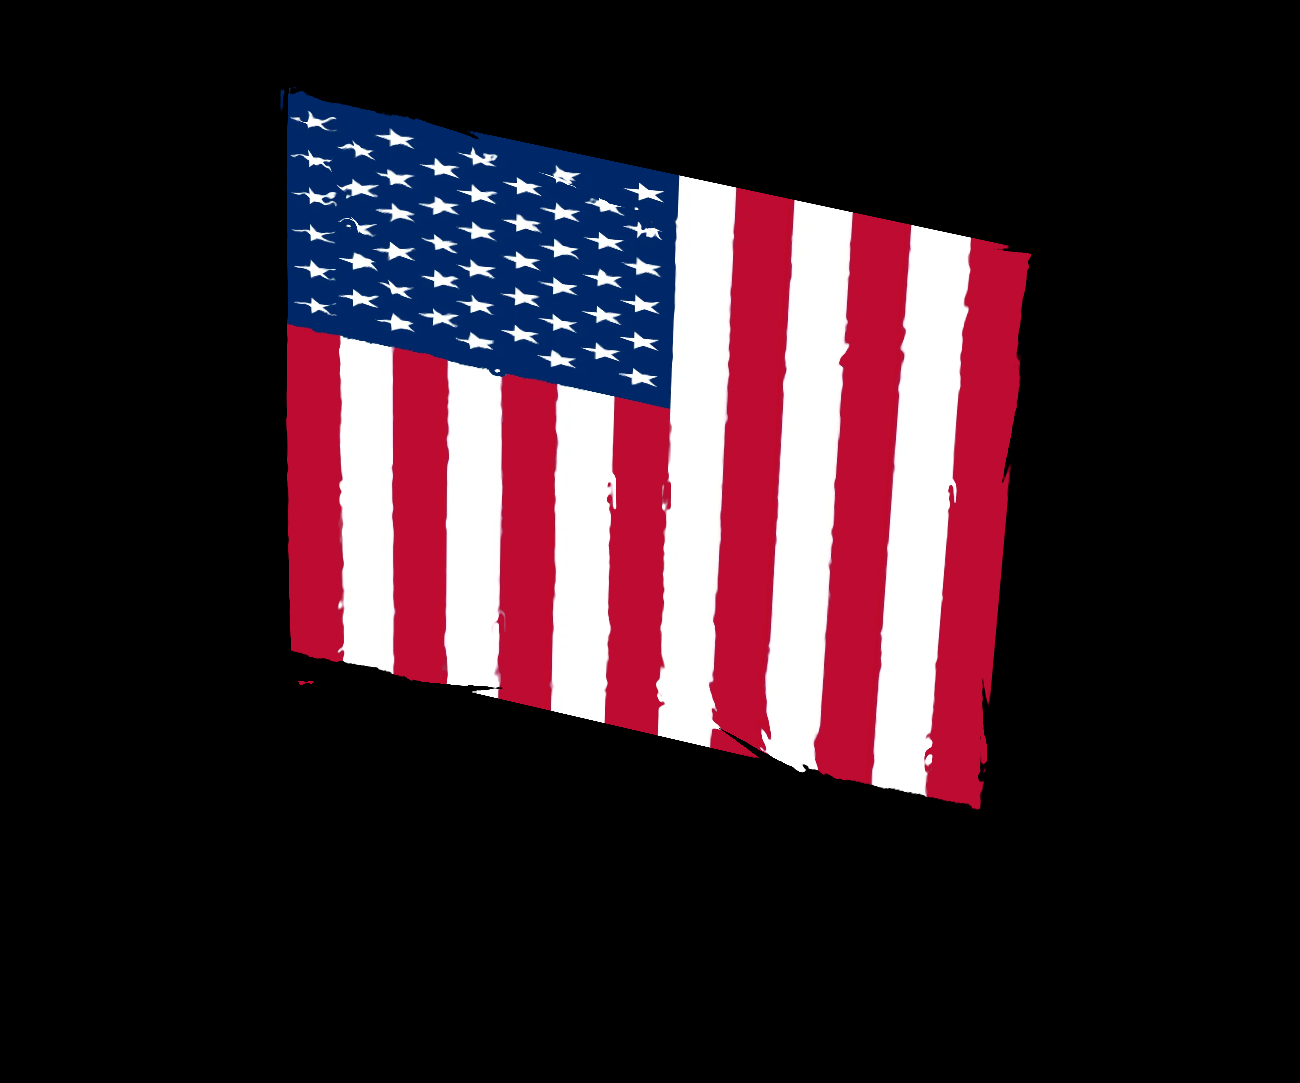

In [16]:
cv2_imshow(deformed.astype(np.uint8))


**Simulate Soft Lighting/Shading**
1. Simulates realistic lighting based on the brightness of the cloth.

2. Brighter areas of the flag enhance the pattern’s brightness.

3. The shading map adjusts pattern luminance to match the flag’s lighting

In [8]:
# Create a soft luminance map by blurring the contrast-enhanced grayscale image
luminance = cv2.GaussianBlur(enhanced, (15, 15), 0).astype(np.float32) / 255.0

# Generate a shading factor by scaling the luminance and clamping values
# This gives darker and lighter areas to simulate shadow and light
shading = np.clip(0.6 + luminance, 0.5, 1.5)

# Apply shading to the deformed image, preserving color and adding depth
shaded = np.clip(deformed.astype(np.float32) * shading[..., None], 0, 255)


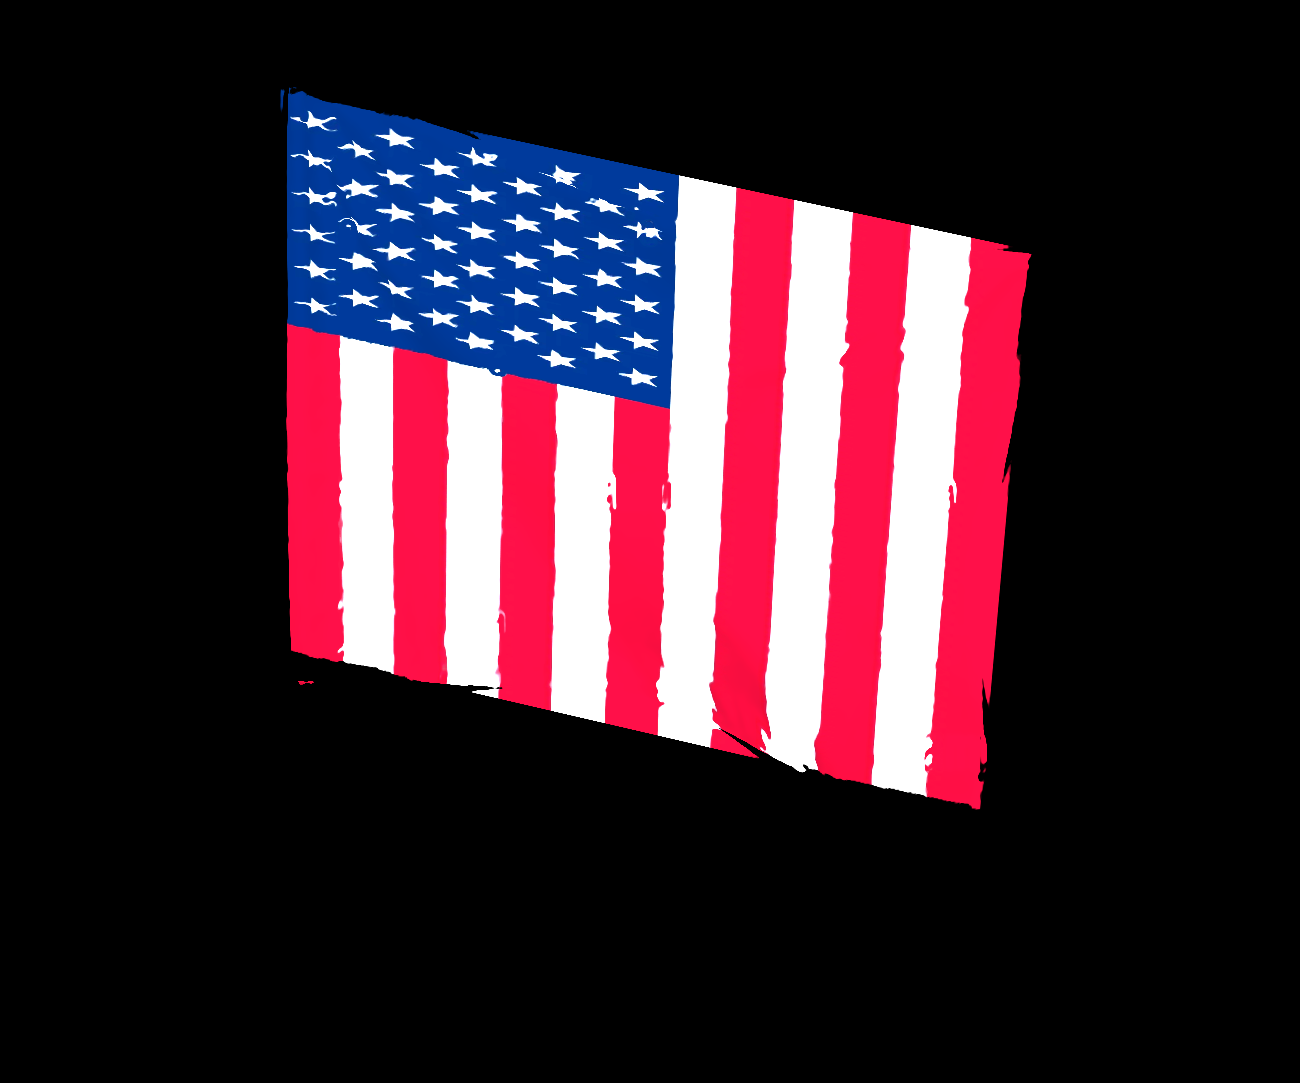

In [17]:
cv2_imshow(shaded.astype(np.uint8))


**Multiply Blend with Base Flag**


1.   Multiply blending: Preserves underlying shadows/folds from the flag image.

2.   Produces more realistic results compared to direct overlay.



In [9]:
# Convert the original flag image to float for precise blending
flag_float = target.astype(np.float32)

# Multiply the shaded pattern with the flag to simulate ink or fabric integration
# This technique darkens the result where either image is dark — similar to screen printing
blended = (shaded / 255.0) * (flag_float / 255.0)

# Scale the blended result back to 0–255 range
blended = blended * 255


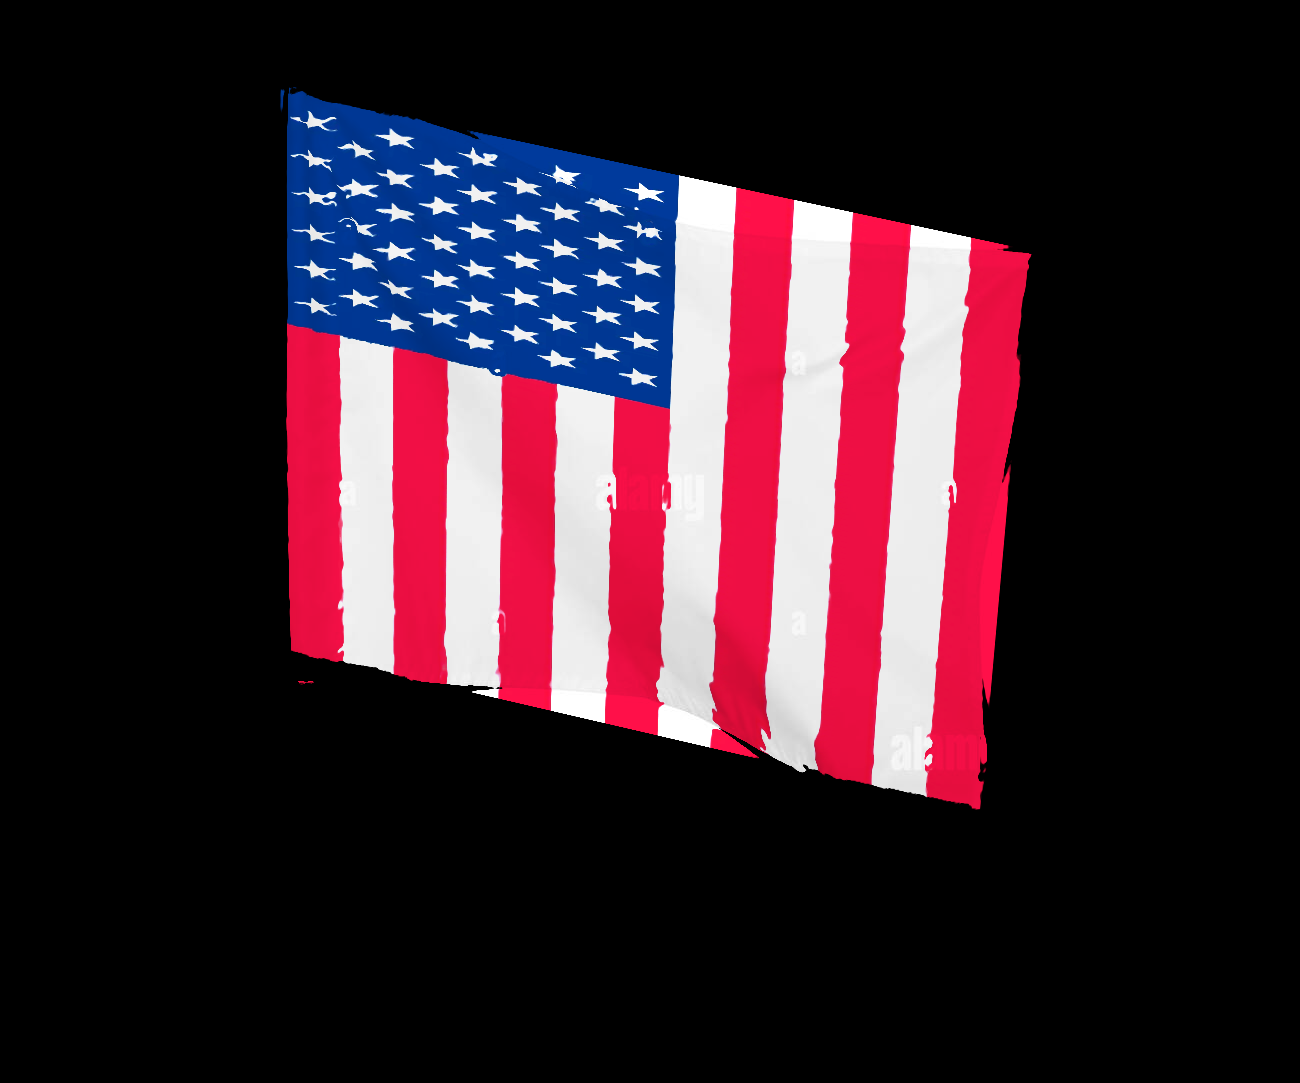

In [18]:
cv2_imshow(blended.astype(np.uint8))


** Final Alpha Blending with Feathered Edges**
1. Combines the soft mask, the multiply-blended image, and the original flag.

2. Alpha blending ensures a smooth transition at the pattern edges.

3. opacity = 0.95 controls how strong the pattern overlay appears.

In [10]:
# Set the desired opacity of the pattern over the flag (e.g., 95%)
opacity = 0.95

# Blend the shaded pattern (blended) with the original flag image (flag_float)
# using the soft alpha mask for smooth edge transitions and realism
final = alpha[..., None] * blended * opacity + (1 - alpha[..., None] * opacity) * flag_float

# Ensure pixel values are valid and convert back to 8-bit image
final = np.clip(final, 0, 255).astype(np.uint8)


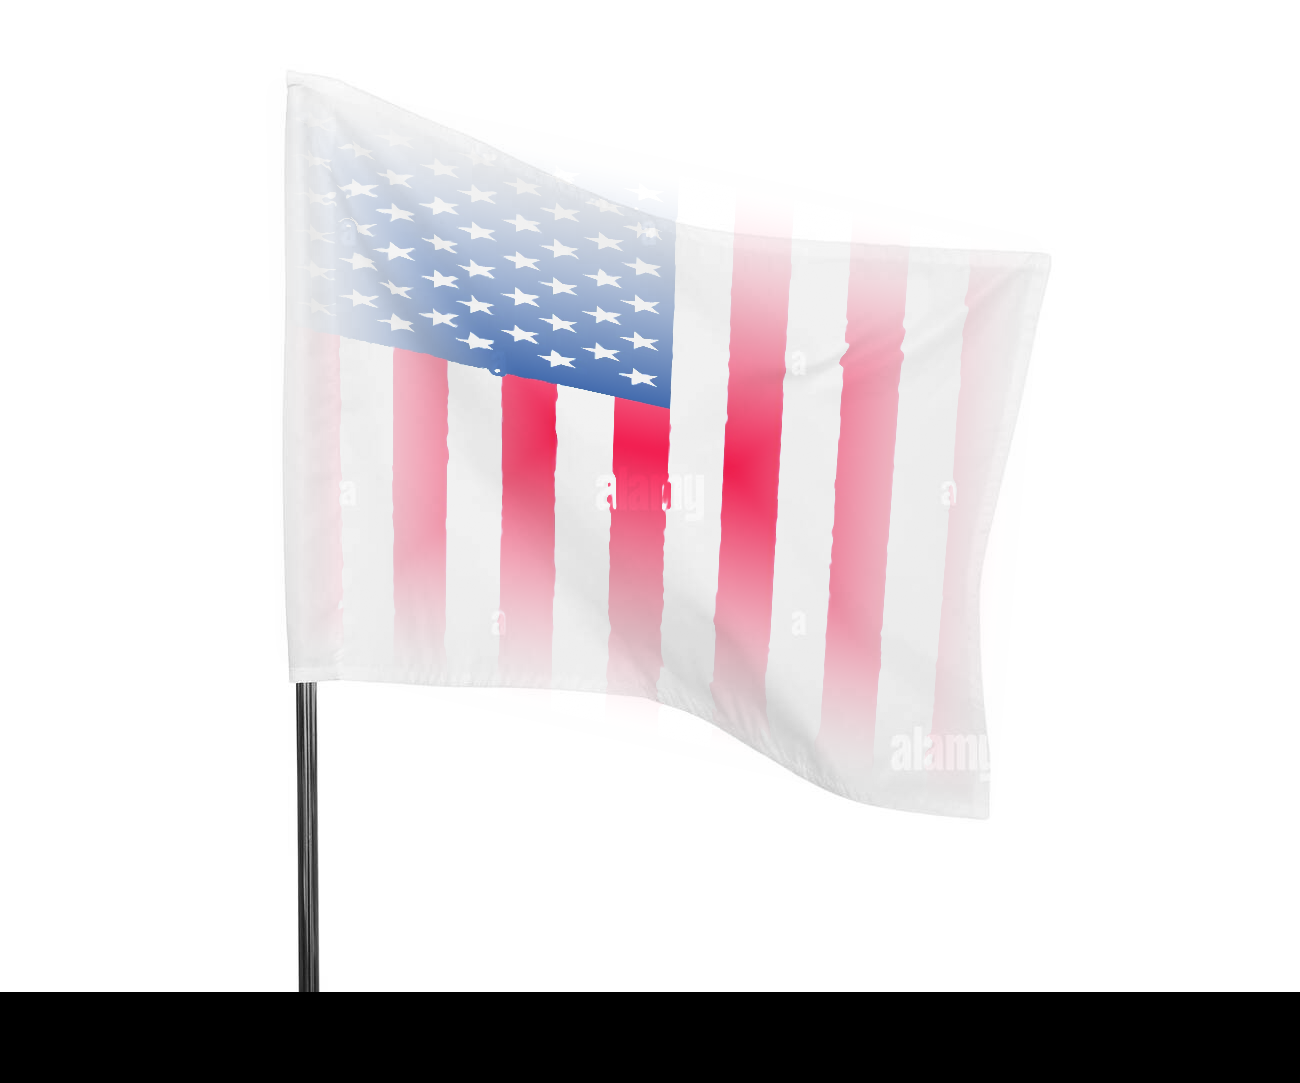

In [11]:
cv2_imshow(final)